In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set a clean visual style for all our charts
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

---
### Step 1 — Load the Data



In [7]:
# Load the test dataset
df = pd.read_csv('data/Test.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nColumn names:')
for col in df.columns:
    print(f'  • {col}')

Dataset shape: 10,086 rows × 12 columns

Column names:
  • country
  • year
  • uniqueid
  • location_type
  • cellphone_access
  • household_size
  • age_of_respondent
  • gender_of_respondent
  • relationship_with_head
  • marital_status
  • education_level
  • job_type


In [9]:
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


---
### Step 2 — SOCIOECONOMIC FOCUS: Education Level

Education is one of the strongest predictors of financial inclusion. Let's explore:
- How education is distributed overall
- How it varies by country
- How it relates to location type (rural vs urban)

In [10]:
# Define a sensible order for education levels (from lowest to highest)
edu_order = [
    'No formal education',
    'Primary education',
    'Secondary education',
    'Vocational/Specialised training',
    'Tertiary education',
    'Other/Dont know/RTA'
]

# Filter to only those that exist in the data
edu_order = [e for e in edu_order if e in df['education_level'].unique()]

edu_counts = df['education_level'].value_counts().reindex(edu_order).dropna()
edu_pct = (edu_counts / edu_counts.sum() * 100).round(1)

print('Education Level Distribution:')
for level, count, pct in zip(edu_counts.index, edu_counts.values, edu_pct.values):
    bar = '█' * int(pct / 2)
    print(f'  {level:<35} {count:>5,}  ({pct:>5.1f}%)  {bar}')

Education Level Distribution:
  No formal education                 1,836  ( 18.2%)  █████████
  Primary education                   5,479  ( 54.3%)  ███████████████████████████
  Secondary education                 1,902  ( 18.9%)  █████████
  Vocational/Specialised training       359  (  3.6%)  █
  Tertiary education                    492  (  4.9%)  ██
  Other/Dont know/RTA                    18  (  0.2%)  


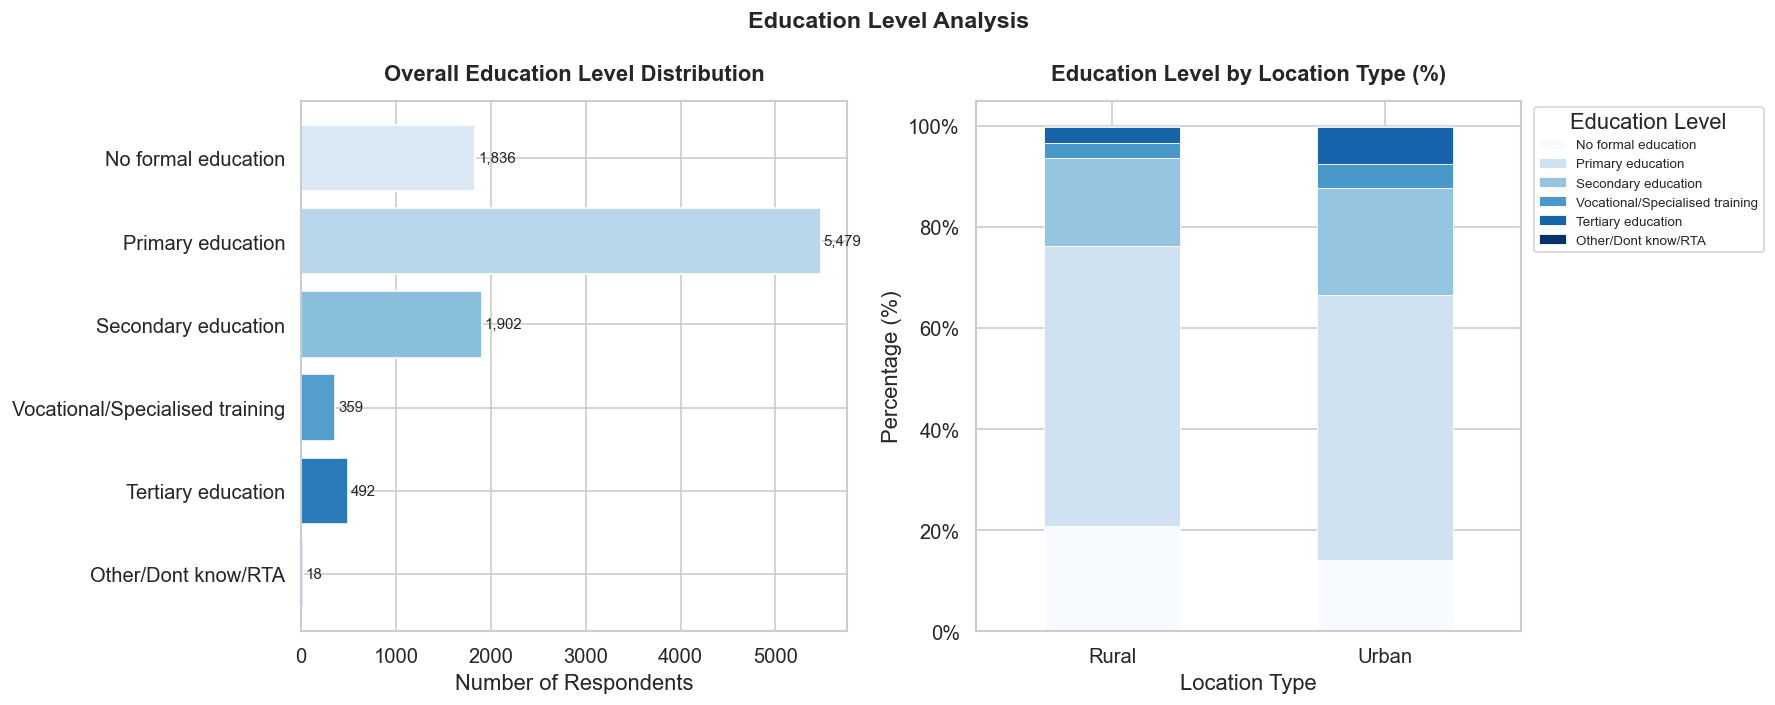

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Overall education distribution ---
palette_edu = sns.color_palette('Blues_r', len(edu_counts))
bars = axes[0].barh(edu_counts.index[::-1], edu_counts.values[::-1],
                    color=palette_edu, edgecolor='white')
axes[0].set_title('Overall Education Level Distribution', fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Respondents')
for bar, val in zip(bars, edu_counts.values[::-1]):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# --- Education by location type (stacked % bar) ---
edu_loc = df.groupby(['location_type', 'education_level']).size().unstack(fill_value=0)
edu_loc = edu_loc.reindex(columns=edu_order, fill_value=0)
edu_loc_pct = edu_loc.div(edu_loc.sum(axis=1), axis=0) * 100

edu_loc_pct.plot(kind='bar', stacked=True, ax=axes[1],
                 colormap='Blues', edgecolor='white', linewidth=0.5)
axes[1].set_title('Education Level by Location Type (%)', fontweight='bold', pad=12)
axes[1].set_xlabel('Location Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Education Level', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Education Level Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

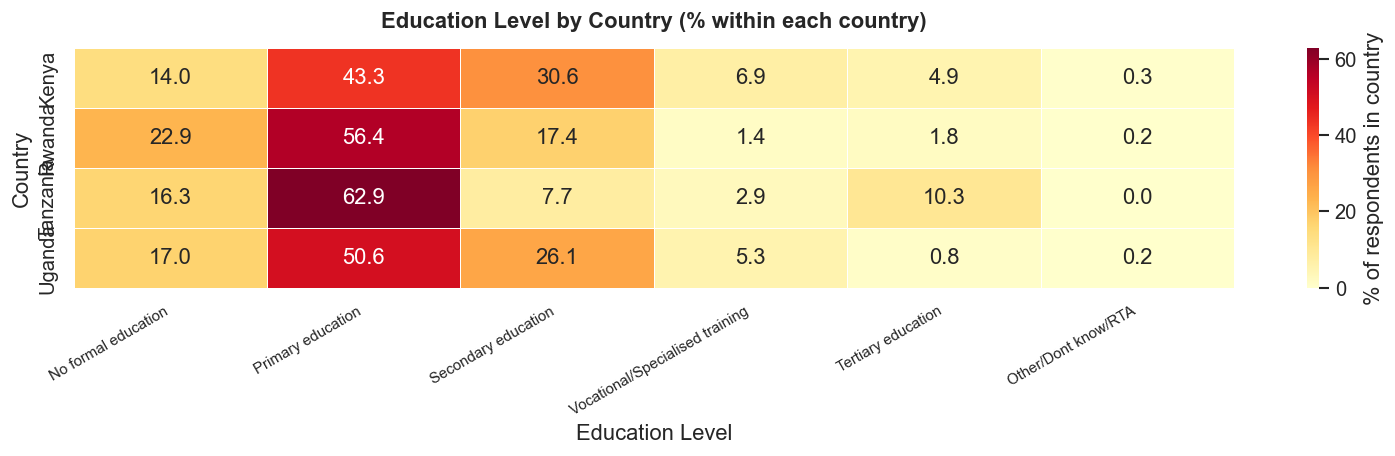

In [20]:
# Education by country — heatmap (% within each country)
edu_country = df.groupby(['country', 'education_level']).size().unstack(fill_value=0)
edu_country = edu_country.reindex(columns=edu_order, fill_value=0)
edu_country_pct = edu_country.div(edu_country.sum(axis=1), axis=0) * 100

plt.figure(figsize=(13, 4))
sns.heatmap(edu_country_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', cbar_kws={'label': '% of respondents in country'})
plt.title('Education Level by Country (% within each country)', fontweight='bold', pad=12)
plt.xlabel('Education Level')
plt.ylabel('Country')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

#Each row shows how education is distributed within that country.
#Countries with more orange/red in higher-education columns are more educated overall

---
### Step 3 — SOCIOECONOMIC FOCUS: Job Type

Employment type is a major socioeconomic indicator. Formally employed individuals typically have more stable income and greater access to financial services. Let's explore how job types are distributed.

In [24]:
# Define a logical order for job types
job_order = [
    'Formally employed Government',
    'Formally employed Private',
    'Informally employed',
    'Self employed',
    'Farming and Fishing',
    'Remittance Dependent',
    'Government Dependent',
    'Other Income',
    'No Income',
    'Dont Know/Refuse to answer'
]
job_order = [j for j in job_order if j in df['job_type'].unique()]

job_counts = df['job_type'].value_counts().reindex(job_order).dropna()
job_pct = (job_counts / job_counts.sum() * 100).round(1)

print('Job Type Distribution:')
for job, count, pct in zip(job_counts.index, job_counts.values, job_pct.values):
    bar_vis = '█' * int(pct / 2)
    print(f'  {job:<40} {count:>5,}  ({pct:>5.1f}%)  {bar_vis}')

Job Type Distribution:
  Formally employed Government               166  (  1.6%)  
  Formally employed Private                  444  (  4.4%)  ██
  Informally employed                      2,372  ( 23.5%)  ███████████
  Self employed                            2,773  ( 27.5%)  █████████████
  Farming and Fishing                      2,370  ( 23.5%)  ███████████
  Remittance Dependent                     1,107  ( 11.0%)  █████
  Government Dependent                       100  (  1.0%)  
  Other Income                               423  (  4.2%)  ██
  No Income                                  276  (  2.7%)  █
  Dont Know/Refuse to answer                  55  (  0.5%)  


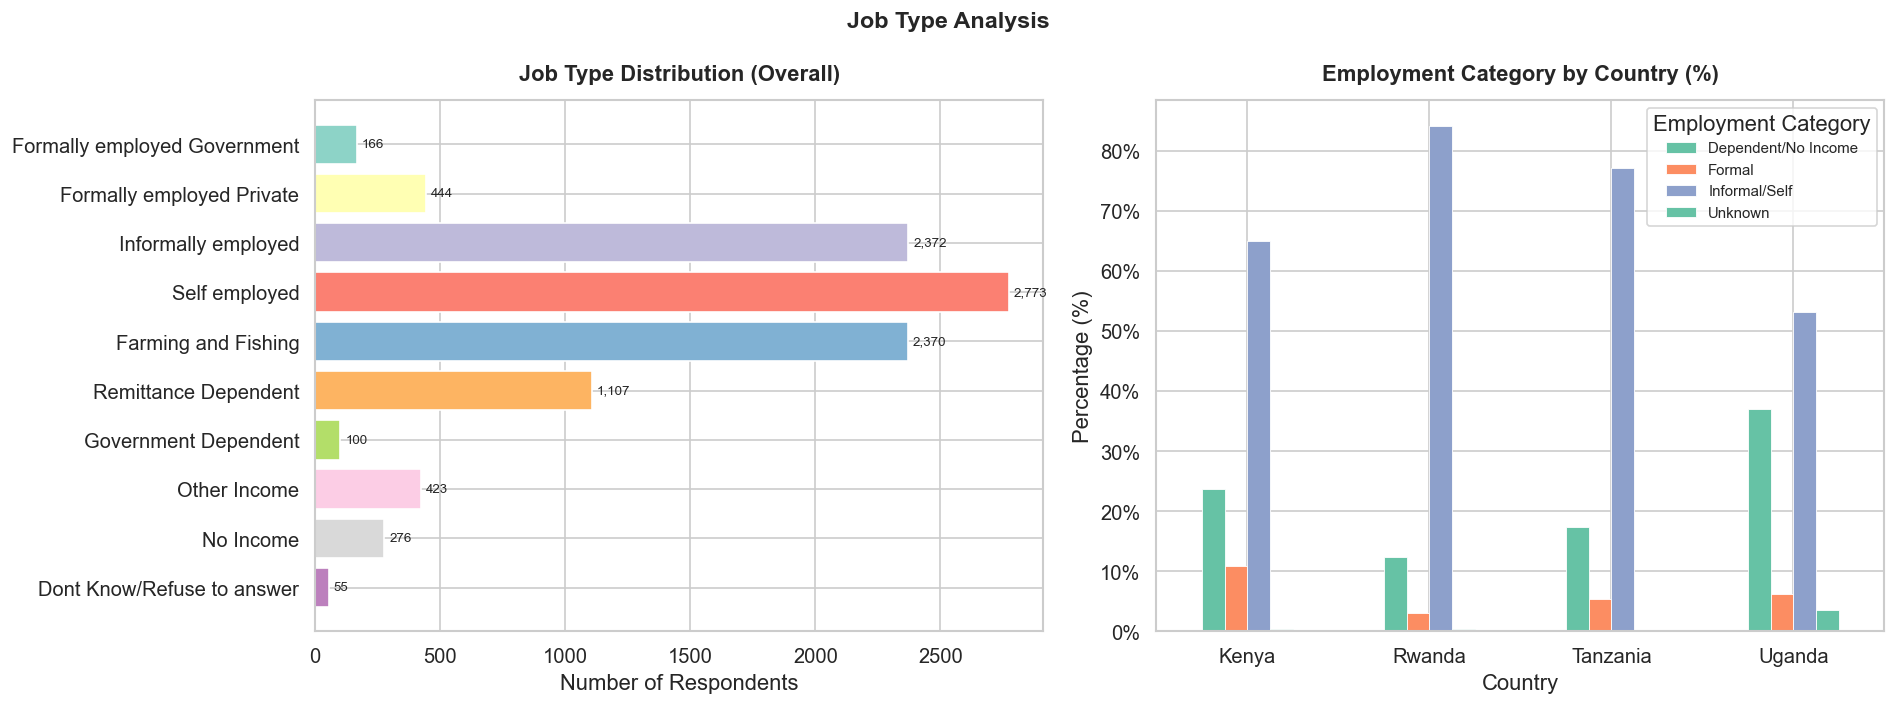

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Horizontal bar chart: overall job type distribution ---
colors_job = sns.color_palette('Set3', len(job_counts))
bars = axes[0].barh(job_counts.index[::-1], job_counts.values[::-1],
                    color=colors_job[::-1], edgecolor='white')
axes[0].set_title('Job Type Distribution (Overall)', fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Respondents')
for bar, val in zip(bars, job_counts.values[::-1]):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# --- Grouped: formal vs informal employment by country ---
formal_jobs = ['Formally employed Government', 'Formally employed Private']
informal_jobs = ['Informally employed', 'Self employed', 'Farming and Fishing']
dependent_jobs = ['Remittance Dependent', 'Government Dependent', 'No Income', 'Other Income']

def categorize_job(job):
    if job in formal_jobs: return 'Formal'
    elif job in informal_jobs: return 'Informal/Self'
    elif job in dependent_jobs: return 'Dependent/No Income'
    else: return 'Unknown'

df['job_category'] = df['job_type'].apply(categorize_job)

job_cat_country = df.groupby(['country', 'job_category']).size().unstack(fill_value=0)
job_cat_pct = job_cat_country.div(job_cat_country.sum(axis=1), axis=0) * 100

job_cat_pct.plot(kind='bar', ax=axes[1],
                 color=sns.color_palette('Set2', 3), edgecolor='white', linewidth=0.5)
axes[1].set_title('Employment Category by Country (%)', fontweight='bold', pad=12)
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Employment Category', fontsize=9)

plt.suptitle('Job Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

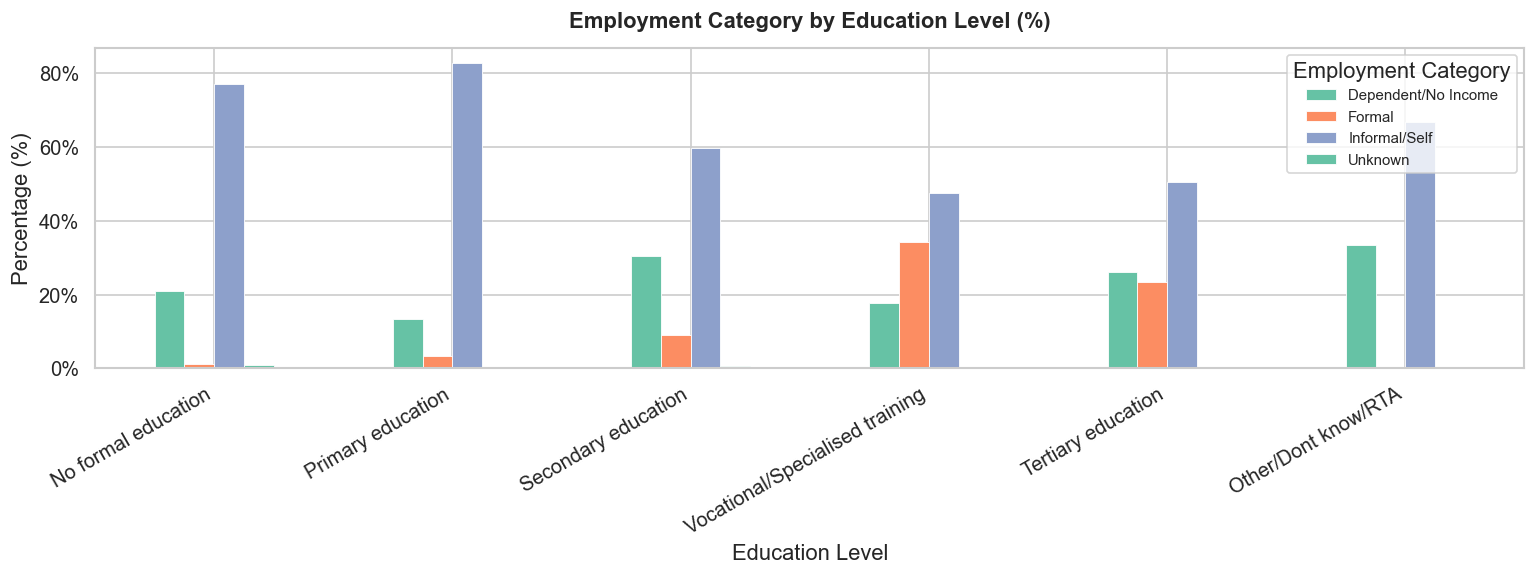

In [27]:
# Job type by education level — do more educated people have formal jobs?
job_edu = df.groupby(['education_level', 'job_category']).size().unstack(fill_value=0)
job_edu = job_edu.reindex(edu_order, fill_value=0)
job_edu_pct = job_edu.div(job_edu.sum(axis=1), axis=0) * 100

job_edu_pct.plot(kind='bar', stacked=False, figsize=(13, 5),
                 color=sns.color_palette('Set2', 3), edgecolor='white', linewidth=0.5)
plt.title('Employment Category by Education Level (%)', fontweight='bold', pad=12)
plt.xlabel('Education Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.yaxis = plt.gca().yaxis
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend(title='Employment Category', fontsize=9)
plt.tight_layout()
plt.show()


---
### Step 4 — SOCIOECONOMIC FOCUS: Cellphone Access

Cellphone access is a critical enabler of mobile money — especially relevant in Africa where mobile banking has grown significantly. Those with a cellphone are much more likely to access financial services digitally.

In [28]:
# Overall cellphone access
phone_counts = df['cellphone_access'].value_counts()
print('Cellphone Access:')
for val, count in phone_counts.items():
    pct = count / len(df) * 100
    bar_vis = '█' * int(pct / 2)
    print(f'  {val:<5}: {count:>5,}  ({pct:.1f}%)  {bar_vis}')

Cellphone Access:
  Yes  : 7,559  (74.9%)  █████████████████████████████████████
  No   : 2,527  (25.1%)  ████████████


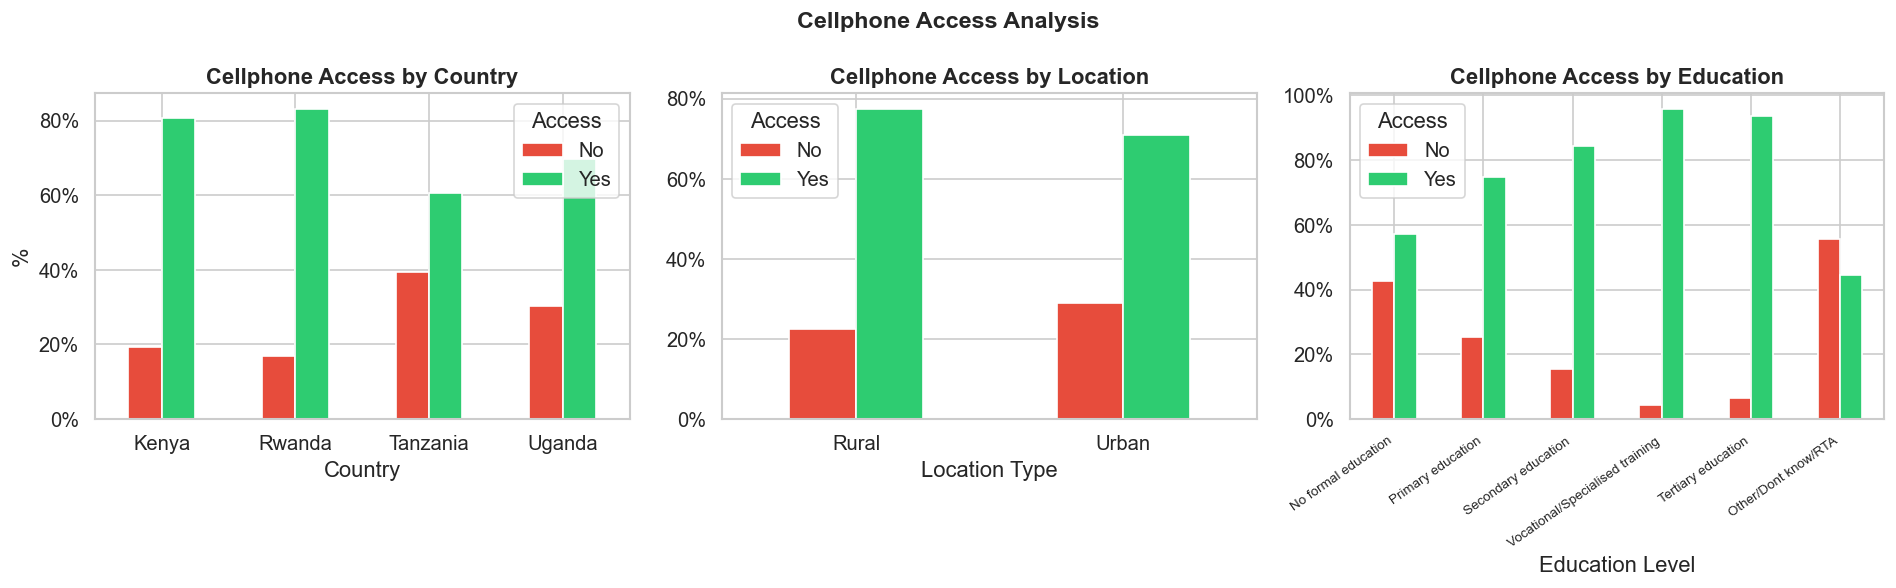

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- By country ---
phone_country = df.groupby('country')['cellphone_access'].value_counts(normalize=True).unstack() * 100
phone_country.plot(kind='bar', ax=axes[0],
                   color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Cellphone Access by Country', fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title='Access')

# --- By location type ---
phone_loc = df.groupby('location_type')['cellphone_access'].value_counts(normalize=True).unstack() * 100
phone_loc.plot(kind='bar', ax=axes[1],
               color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Cellphone Access by Location', fontweight='bold')
axes[1].set_xlabel('Location Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Access')

# --- By education level ---
phone_edu = df.groupby('education_level')['cellphone_access'].value_counts(normalize=True).unstack() * 100
phone_edu = phone_edu.reindex(edu_order)
phone_edu.plot(kind='bar', ax=axes[2],
               color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[2].set_title('Cellphone Access by Education', fontweight='bold')
axes[2].set_xlabel('Education Level')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].legend(title='Access')

plt.suptitle('Cellphone Access Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

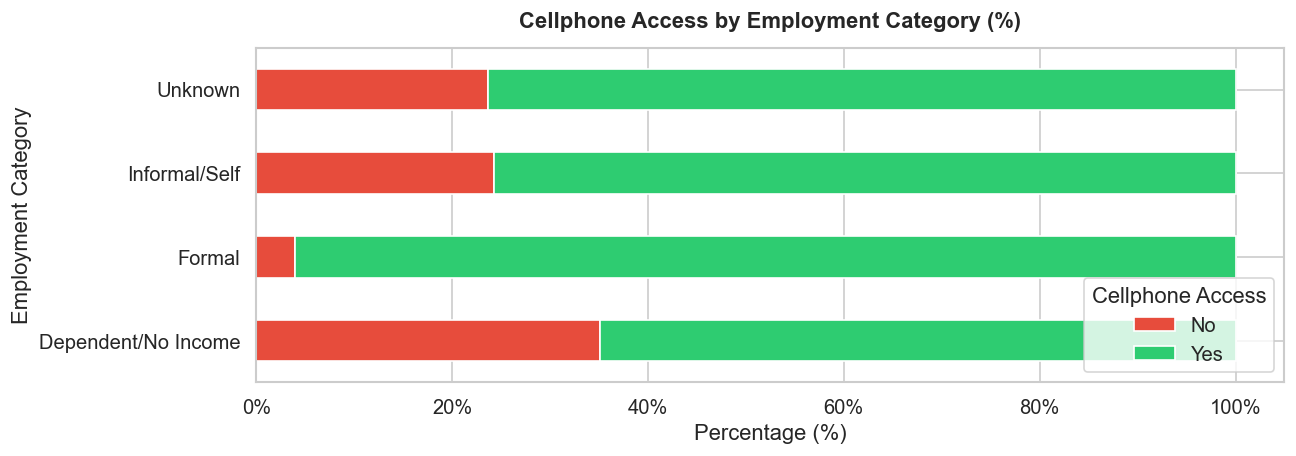

In [31]:
# Cellphone access by job category
phone_job = df.groupby('job_category')['cellphone_access'].value_counts(normalize=True).unstack() * 100

phone_job.plot(kind='barh', stacked=True, figsize=(11, 4),
               color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title('Cellphone Access by Employment Category (%)', fontweight='bold', pad=12)
plt.xlabel('Percentage (%)')
plt.ylabel('Employment Category')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend(title='Cellphone Access', loc='lower right')
plt.tight_layout()
plt.show()


---
### Step 5 — Summary & Key Findings

Let's compile the key statistics from our socioeconomic analysis.

In [38]:
print('=' * 65)
print('    EDA SUMMARY — Financial Inclusion in Africa (Test Set)')
print('=' * 65)

print(f'\n DATASET OVERVIEW')
print(f'   Total respondents  : {len(df):,}')
print(f'   Countries          : {", ".join(df["country"].unique())}')
print(f'   Missing values     : {df.isnull().sum().sum()}')

print(f'\n EDUCATION')
top_edu = df['education_level'].value_counts().index[0]
top_edu_pct = df['education_level'].value_counts(normalize=True).iloc[0] * 100
print(f'   Most common level  : {top_edu} ({top_edu_pct:.1f}%)')
tertiary_pct = (df['education_level'] == 'Tertiary education').mean() * 100
print(f'   Tertiary education : {tertiary_pct:.1f}% of respondents')
no_edu_pct = (df['education_level'] == 'No formal education').mean() * 100
print(f'   No formal education: {no_edu_pct:.1f}% of respondents')

print(f'\n EMPLOYMENT')
formal_pct = (df['job_category'] == 'Formal').mean() * 100
informal_pct = (df['job_category'] == 'Informal/Self').mean() * 100
dep_pct = (df['job_category'] == 'Dependent/No Income').mean() * 100
print(f'   Formally employed  : {formal_pct:.1f}%')
print(f'   Informal/Self      : {informal_pct:.1f}%')
print(f'   Dependent/No Income: {dep_pct:.1f}%')

print(f'\n CELLPHONE ACCESS')
phone_yes = (df['cellphone_access'] == 'Yes').mean() * 100
print(f'   Has cellphone      : {phone_yes:.1f}%')
print(f'   No cellphone       : {100-phone_yes:.1f}%')

# Cellphone access gap between urban and rural
urban_phone = df[df['location_type'] == 'Urban']['cellphone_access'].eq('Yes').mean() * 100
rural_phone = df[df['location_type'] == 'Rural']['cellphone_access'].eq('Yes').mean() * 100
print(f'   Urban access rate  : {urban_phone:.1f}%')
print(f'   Rural access rate  : {rural_phone:.1f}%')
print(f'   Urban-Rural gap    : {urban_phone - rural_phone:.1f} percentage points')

print(f'\n SOCIOECONOMIC SCORE (0–7 composite)')
print(f'   Mean score         : {df["socioeconomic_score"].mean():.2f}')
print(f'   Median score       : {df["socioeconomic_score"].median():.2f}')
print(f'   Score by country   :')
for country, score in df.groupby('country')['socioeconomic_score'].mean().sort_values(ascending=False).items():
    print(f'     {country:<10}: {score:.2f}')


    EDA SUMMARY — Financial Inclusion in Africa (Test Set)

 DATASET OVERVIEW
   Total respondents  : 10,086
   Countries          : Kenya, Rwanda, Tanzania, Uganda
   Missing values     : 0

 EDUCATION
   Most common level  : Primary education (54.3%)
   Tertiary education : 4.9% of respondents
   No formal education: 18.2% of respondents

 EMPLOYMENT
   Formally employed  : 6.0%
   Informal/Self      : 74.5%
   Dependent/No Income: 18.9%

 CELLPHONE ACCESS
   Has cellphone      : 74.9%
   No cellphone       : 25.1%
   Urban access rate  : 71.0%
   Rural access rate  : 77.5%
   Urban-Rural gap    : -6.5 percentage points

 SOCIOECONOMIC SCORE (0–7 composite)
   Mean score         : 2.84
   Median score       : 3.00
   Score by country   :
     Kenya     : 3.13
     Tanzania  : 2.76
     Rwanda    : 2.76
     Uganda    : 2.57
